# Network Vulnerabilities

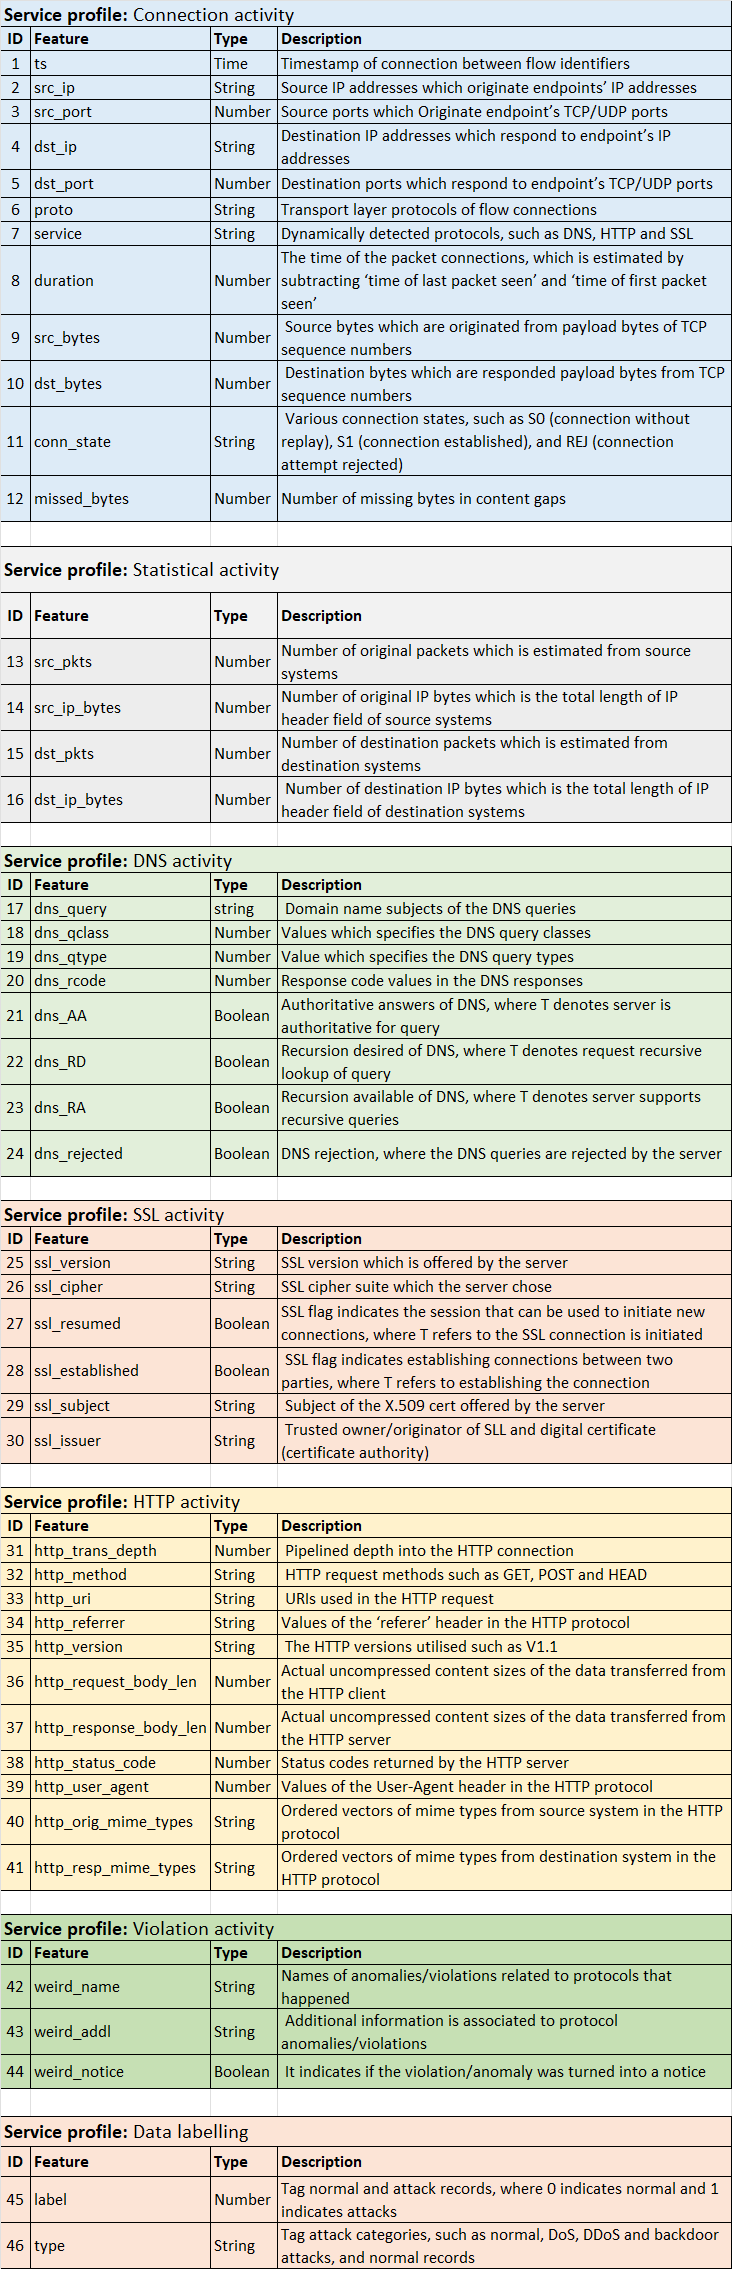

# Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_test_network.csv')

In [35]:
df_original=df.copy()

In [16]:
df.shape

(211043, 44)

In [6]:
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [7]:
df.tail()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,-,-,-,-,-,-,1,xss
211042,192.168.1.32,48304,176.28.50.165,80,tcp,http,65.771855,3181,322,S3,...,0,0,-,-,-,-,-,-,1,xss


In [8]:
df.columns

Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')

# Split the Train and test

In [18]:
df['type'].unique()

array(['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal',
       'password', 'ransomware', 'scanning', 'xss'], dtype=object)

In [36]:
target= df['type']

In [37]:
df= df.drop('type', axis=1)

In [38]:
X_train, x_test, Y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=4 ,stratify=target, )

In [9]:
X_train.shape

(168834, 43)

# Exploratory Data Analysis

In [40]:
#Join X_train and Y_train
train=pd.concat([X_train, Y_train], axis=1)

In [31]:
train.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
134330,192.168.1.31,53608,192.168.1.195,80,tcp,http,0.025442,155,978,SF,...,0,0,-,-,-,-,-,-,1,password
11635,192.168.1.193,49776,192.168.1.37,8080,tcp,-,0.000156,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
120791,192.168.1.184,8080,192.168.1.184,1244,tcp,-,0.216804,0,0,S0,...,0,0,-,-,-,-,-,-,0,normal
2407,192.168.1.193,49415,192.168.1.33,80,tcp,-,0.000125,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
28468,192.168.1.30,33354,192.168.1.190,80,tcp,-,0.000017,0,0,S1,...,0,0,-,-,-,-,-,-,1,ddos


In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168834 entries, 134330 to 197417
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  168834 non-null  object 
 1   src_port                168834 non-null  int64  
 2   dst_ip                  168834 non-null  object 
 3   dst_port                168834 non-null  int64  
 4   proto                   168834 non-null  object 
 5   service                 168834 non-null  object 
 6   duration                168834 non-null  float64
 7   src_bytes               168834 non-null  int64  
 8   dst_bytes               168834 non-null  int64  
 9   conn_state              168834 non-null  object 
 10  missed_bytes            168834 non-null  int64  
 11  src_pkts                168834 non-null  int64  
 12  src_ip_bytes            168834 non-null  int64  
 13  dst_pkts                168834 non-null  int64  
 14  dst_ip_bytes        

columns with wrong datatypes:
- http_user_agent: should be integer
- http_trans_depth: should be integer

Can't change yet because of missing values

In [ ]:
#train['http_user_agent']= train['http_user_agent'].astype("int")
#train['http_trans_depth']= train['http_trans_depth'].astype("int")

In [41]:
train['http_user_agent'].unique()

array(['-', 'Microsoft-Delivery-Optimization/10.0',
       'Windows-Update-Agent/10.0.10011.16384 Client-Protocol/1.91',
       'User-Agent: Microsoft-DLNA DLNADOC/1.50',
       'Debian APT-HTTP/1.3 (1.7.4)', 'Microsoft-Windows/10.0 UPnP/1.0',
       'Mozilla/5.0 (SMART-TV; Linux; Tizen 2.3) AppleWebkit/538.1 (KHTML; like Gecko) SamsungBrowser/1.0 Safari/538.1',
       'Ruby', 'DAFUPnP',
       'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:66.0) Gecko/20100101 Firefox/66.0',
       'hacking',
       'Mozilla/5.0 (compatible; MSIE 10.0; Windows NT 6.1; Trident/4.0; InfoPath.2; SV1; .NET CLR 2.0.50727; WOW64)',
       'DonutP; Windows98SE', 'Microsoft-WNS/10.0',
       'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_12_0) AppleWebKit/537.36 (KHTML; like Gecko) Chrome/53.0.2785.143 Safari/537.36',
       'MICROSOFT_DEVICE_METADATA_RETRIEVAL_CLIENT',
       'Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebKit/537.36 (KHTML; like Gecko) Chrome/53.0.2785.143 Safari/537.36',
       'Mozilla/5.0 (iPhone;

## Missing Values

In [41]:
train.isna().sum()

,0
src_ip,0
src_port,0
dst_ip,0
dst_port,0
proto,0
service,0
duration,0
src_bytes,0
dst_bytes,0
conn_state,0


No missing values but should check missing values in other forms

In [11]:
numeric_features= train.select_dtypes(include=np.number)

In [12]:
numeric_features.columns

Index(['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes',
       'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'label'],
      dtype='object')

In [13]:
categorical_features= train.select_dtypes(include=['object'])
categorical_features.columns

Index(['src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'dns_query',
       'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version',
       'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject',
       'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri',
       'http_version', 'http_user_agent', 'http_orig_mime_types',
       'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice',
       'type'],
      dtype='object')

In [68]:
train[train['http_trans_depth'].str.contains('-')]

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
134330,192.168.1.31,53608,192.168.1.195,80,tcp,http,0.025442,155,978,SF,...,0,0,-,-,-,-,-,-,1,password
11635,192.168.1.193,49776,192.168.1.37,8080,tcp,-,0.000156,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
120791,192.168.1.184,8080,192.168.1.184,1244,tcp,-,0.216804,0,0,S0,...,0,0,-,-,-,-,-,-,0,normal
2407,192.168.1.193,49415,192.168.1.33,80,tcp,-,0.000125,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
28468,192.168.1.30,33354,192.168.1.190,80,tcp,-,0.000017,0,0,S1,...,0,0,-,-,-,-,-,-,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40717,192.168.1.30,47259,192.168.1.1,53,udp,dns,0.002479,35,67,SF,...,0,0,-,-,-,-,-,-,1,dos
148028,192.168.1.30,53710,192.168.1.152,80,tcp,http,0.003341,153,463,SF,...,0,0,-,-,-,-,-,-,1,password
190030,192.168.1.32,53036,192.168.1.49,79,tcp,-,0.000000,0,0,S0,...,0,0,-,-,-,-,-,-,1,scanning
106938,192.168.1.152,38999,192.168.1.190,53,udp,dns,0.000078,130,0,S0,...,0,0,-,-,-,-,-,-,0,normal


In [80]:
#Checking the categorical columns with '-' on it
for col in categorical_features:
  if train[col].str.contains('-').any():
    print(col)

service
dns_query
dns_AA
dns_RD
dns_RA
dns_rejected
ssl_version
ssl_cipher
ssl_resumed
ssl_established
ssl_subject
ssl_issuer
http_trans_depth
http_method
http_uri
http_version
http_user_agent
http_orig_mime_types
http_resp_mime_types
weird_name
weird_addl
weird_notice


In [42]:
#Checking the categorical columns with int on it
for col in categorical_features:
  if train[col].str.isnumeric().any():
    print(col)

http_trans_depth
weird_addl


In [44]:
#replacing - by nan in http_trans_depth
train['http_trans_depth']=train['http_trans_depth'].replace('-', np.nan)

In [25]:
train['http_trans_depth'].unique()

array([nan, '1', '9', '2', '6', '3', '7', '5', '4', '10', '8'],
      dtype=object)

In [43]:
train['weird_addl'].unique()

array(['-', '46', '48'], dtype=object)

In [46]:
#replacing - by nan in '-'
train['weird_addl']= train['weird_addl'].replace('-', np.nan)

In [23]:
train.shape

(168834, 44)

In [47]:
train.isna().sum()

,0
src_ip,0
src_port,0
dst_ip,0
dst_port,0
proto,0
service,0
duration,0
src_bytes,0
dst_bytes,0
conn_state,0


Replacing missing values

In [56]:
train['http_trans_depth']= train['http_trans_depth'].replace(np.nan,'0')

In [ ]:
train['weird_addl']=train['weird_addl']

## Duplicates

In [51]:
train.duplicated().sum()

np.int64(15357)

In [55]:
train= train.drop_duplicates()

In [86]:
train.duplicated().sum()

np.int64(0)

## Data types

## Univariate Analysis

## Bivariate Analysis